# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 3, <font color="blue">легкая часть</font>. Линейная и логистическая регрессии.


**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить телеграм-боту `@thetahat_ds25_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайн см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**. Если вы строите интерактивные графики, их стоит прислать в формате html.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания всем участникам списывания дается штраф -2 балла к итоговой оценке за семестр.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.

**Правила оформления теоретических задач:**

* Решения необходимо оформить в виде $\LaTeX$ в markdown-ячейках. Иные способы (в т.ч. фотографии) не принимаются.
* Если вы не знаете $\LaTeX$, используйте ИИ-инструменты для оформления черновика решения. Примеры были показаны на лекции 2 по ИИ-инструментам.
* **В решениях поясняйте, чем вы пользуетесь**, хотя бы кратко. 
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.


<b><font size="5" color="red">Важно!!! Правила заполнения ноутбука:</font></b>
* Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения задач.
* Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз.
* Отвечайте на вопросы, а также добавляйте новые ячейки в предложенных местах, которые обозначены `<...>`.
* В markdown-ячейка, содержащих описание задачи, находятся специальные отметки, которые <font color="red"><b>запрещается модифицировать</b></font>.
* При нарушении данных правил работа может получить 0 баллов.


**Баллы за задание:**

<b><font color="blue">Легкая часть</font></b> (достаточно на "хор"):

* Задача 1 &mdash; 20 баллов
* Задача 2 &mdash; 80 баллов
* Задача 3 &mdash; 30 баллов;
* Задача 4 &mdash; 20 баллов;

<b><font color="orange">Сложная часть</font></b> (необходимо на "отл"):

* Задачи 5-7: скачайте второй ноутбук с условием задания со страницы курса.

Баллы учитываются в <b>обязательной части</b> курса и не влияют на оценку по факультативной части.

In [ ]:
# Bot check

# HW_ID: fpmi_ad3_part1
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="Set2")

При решении задания используйте `sklearn`. Пропишите сюда необходимые импорты

In [64]:
from typing import Tuple, Optional, Any, Dict, List

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
random_state = 42

---
### <font color="blue"><i>Легкая часть</i></font>

---
### Задача 1.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 146d04157c07b08ee58d3eafdcf82c32 -->
Рассмотрим модель одномерной линейной регрессии *без свободного параметра* $y(x) = \theta x$, где $x\in \mathbb{R}$ и $\theta \in \mathbb{R}$. Предполагаем, что данные получены по правилу
$$Y_i = \theta x_i + \varepsilon_i,$$
где $i \in \{1, ..., n\}$, числа $x_i \in \mathbb{R}$ неслучайны, а $\varepsilon_i$ &mdash; случайные ошибки.

**1.** Посчитайте оценку $\widehat{\theta}$ методом наименьших квадратов по явной формуле.

**2.** Выпишите формулы итераций градиентного спуска (GD) и стохастического градиентного спуска (SGD) для поиска $\widehat{\theta}$. Не забудьте указать, как в SGD математически определяется батч (набор объектов на каждой итерации).

**3.** Опишите, что произойдет, если для некоторого $i$ ошибка $\varepsilon_i$ будет очень большой.


*Замечания.*
1. Это теоретическая задача, не перепутайте 😄
2. В ответе во всех пунктах могут оставаться суммы $n$ слагаемых, но не должно быть операций с векторами или матрицами.
3. **Прочитайте требования к формату решения в правилах сдачи задания.**

**Решение:**

### Пункт 1
Оценку $\hat{\theta}$ можно посчитать по формуле $\hat{\theta} = (X^T X)^{-1} X^T Y$, где X - столбец **объектов**, а Y - стобец их **таргетов**, то есть


$$
X = \begin{pmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{pmatrix}, \quad
Y = \begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{pmatrix}
$$

$\hat{\theta} = (X^T X)^{-1} X^T Y = 
(\sum_{i=1}^{n} x_i^2) \cdot (\sum_{i=1}^{n} x_iy_i) =
\sum_{i=1}^{n} \sum_{j=1}^n x_i^2 x_j y_j$

### Пункт 2
Обычно в линейной регрессии используется **среднеквадратичная ошибка (MSE)** как функция потерь. Для всего набора данных с $n$ объектов она записывается как:

$$
L(\theta) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{n} \sum_{i=1}^{n} (y_i - \theta x_i)^2
$$

Это функция потерь, которую мы минимизируем с помощью градиентного или стохастического градиентного спуска.

### Градиентный спуск (GD)
Для минимизации $L(\theta)$ вычисляем градиент по $\theta$. Так как $\theta$ только одна, градиент вырождается в произодную:

$$
\nabla L(\theta) = \frac{\partial L(\theta)}{\partial \theta} = \frac{1}{n} \sum_{i=1}^{n} \frac{\partial}{\partial \theta} (y_i - \theta x_i)^2
$$

Считаем производную:
$$
\frac{\partial}{\partial \theta} (y_i - \theta x_i)^2 = -2 (y_i - \theta x_i) x_i
$$

Тогда:
$$
\nabla L(\theta) = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \theta x_i) x_i
$$

Итерация GD:
$$
\theta_{t+1} = \theta_t - \eta \cdot \nabla L(\theta_t) = \theta_t + \frac{2\eta}{n} \sum_{i=1}^{n} (y_i - \theta_t x_i) x_i
$$

Часто, все коэффиценты вычисленные в члене с функцией потерь заносяться в $\eta$, т.е. итерация градиентного спуска выглядит так:
$$
\theta_{t+1} = \theta_t + \eta \sum_{i=1}^{n} (y_i - \theta_t x_i) x_i
$$

### Стохастический градиентный спуск (SGD)
В SGD мы используем батч $B_t$ вместо всего набора данных. Градиент(в нашем случае производная) вычисляется по подмножеству объектов:

$$
\nabla L_{B}(\theta) = -\frac{2}{|B|} \sum_{i \in B} (y_i - \theta x_i) x_i
$$

Итерация SGD:
$$
\theta_{t+1} = \theta_t - \eta \cdot \nabla L_{B}(\theta_t) = \theta_t + \frac{2\eta}{|B|} \sum_{i \in B} (y_i - \theta_t x_i) x_i
$$

- $|B|$ — размер батча,
- $B$ — случайное подмножество индексов $\{1, 2, \dots, n\}$.

Аналогично GD, иногда все коэффиценты вычисленные в члене с функцией потерь заносяться в $\eta$:
$$
\theta_{t+1} = \theta_t + \eta\sum_{i \in B} (y_i - \theta_t x_i) x_i
$$

Для выбора батча используют обычный линейный проход по выборке. В начале алгоритма выборка случайным образом перемешивается. Далее берем первые $|B|$ элементов из выборки, обновляем значение $\theta$ и идем к следующим $|B|$ элементам. При этом вводится понятие эпохи. Одна эпоха это полный проход по выборке, после которого обход начинается заново. Заметим, что если выборка очень большая, то даже первый проход бывает можно не заканчивать.

### Пункт 3

Линейная регрессия чувствительна к выбросам, так как минимизирует сумму квадратов ошибок. Большая ошибка для одного объекта может "потянуть" линию регрессии в его сторону, что ухудшит качество предсказаний для остальных данных. 

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 00000000000000000000000000000000 -->
---
### Задача 2.

*Перед выполнением задачи ознакомтесь с <a href="https://thetahat.ru/courses/ad/main/3/ad_linreg_sklearn">ноутбуком по линейной регрессии</a> с занятия.*

Скоро весна и лето &mdash; идеальное время года для путешествий и прогулок на велосипедах. В крупных городах обычно развиты сети проката велосипедов или самокатов, предоставляющие удобный сервис. Одной из важных задач таких компаний является прогнозирование количества арендованных велосипедов в зависимости от времени года и погодных условий.

Рассмотрим датасет <a target="_blank" href="https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset">Bike Sharing Dataset</a> от компании <a target="_blank" href="https://www.capitalbikeshare.com/">Capital Bikeshare</a>, располагающей автоматизированными пунктами проката велосипедов. В датасете по дням записаны календарная информация и погодные условия, а также число прокатов в этот день. Цель &mdash; предсказать количество арендованных велосипедов по остальным характеристикам.

<img src="https://thetahat.ru/files/ad/main/3/bike1.jpeg">

Будем работать только со следующими признаками:
* `season`: время года: 1 &mdash; зима, 2 &mdash; весна, 3 &mdash; лето, 4 &mdash; осень;
* `mnth`: месяц от 1 до 12;
* `holiday`: является ли текущий день праздничным;
* `weekday`: день недели от 0 до 6;
* `workingday`: является ли текущий день рабочим или выходным;
* `weathersit`: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман);
* `temp`: температура в Цельсиях;
* `atemp`: температура по ощущениям в Цельсиях;
* `hum`: влажность воздуха;
* `windspeed`: скорость ветра;
* `cnt`: количество арендованных велосипедов в текущий день.

---

Скачайте данные, загрузите их с помощью `pandas` и разделите на обучающую и тестовую части в соотношении 4:1. Далее всю аналитику необходимо проводить только на обучающей части данных.

Загружаем данные

In [134]:
data = pd.read_csv("day.csv")

Выделим таргеты и характеристики объектов

In [146]:
categorial_features = ["mnth", "season", "holiday", "weekday", "weathersit", "workingday"]
real_features = ["atemp", "hum", "temp", "windspeed"]
target_feature = ["cnt"]
all_features = ["season", "mnth", "holiday", "weekday", "workingday", "weathersit", "temp",	"atemp", "hum",	"windspeed", "cnt"]

In [136]:
data = data[all_features]

Разделим выборку на тестовую и тренировчную

In [137]:
train, test = train_test_split(data, test_size=0.2,random_state=random_state)
train.shape, test.shape

((584, 11), (147, 11))

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 7e2346d718d374e3f957928b573e2a30 -->
#### 1. Визуальный анализ

Посмотрите по графикам, как *целевой признак зависит от остальных* и поймите характер этой зависимости. Старайтесь строить информативные графики, а из финального решения убирать те, которые не пригодились.

Какие признаки категориальные, а какие &mdash; вещественные? Учтите это при построении информативных графиков.

*Указание*. Среди признаков есть такие, значения которых как-то упорядочены, и их относительно небольшое количество. Чтобы понять, являются ли они категориальными, попробуйте понять, как с их значениями будут работать линейные модели. Иначе говоря, допустимо ли с точки зрения природы данных выполнять арифметические операции между *любыми* значениями этого признака, согласуется ли это со смыслом, который несет в себе данный признак?

Построим несколько графиков для того, чтобы определить, от каких параметров зависят таргеты

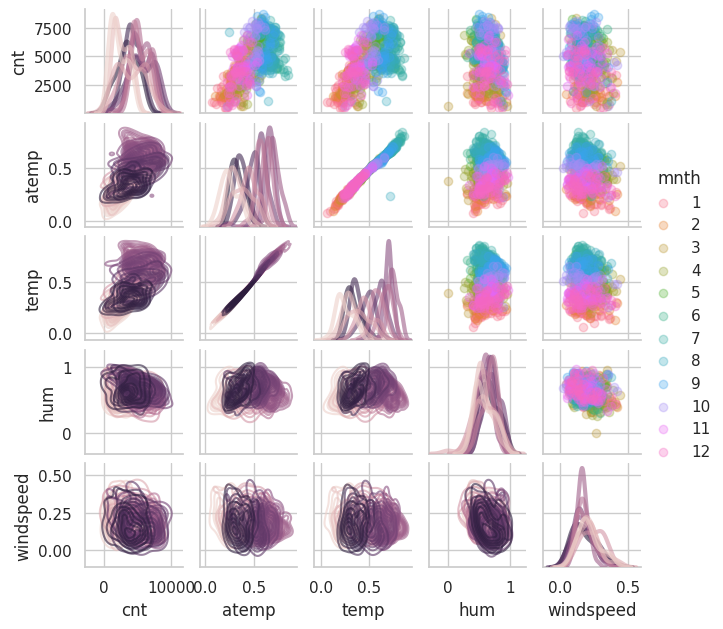

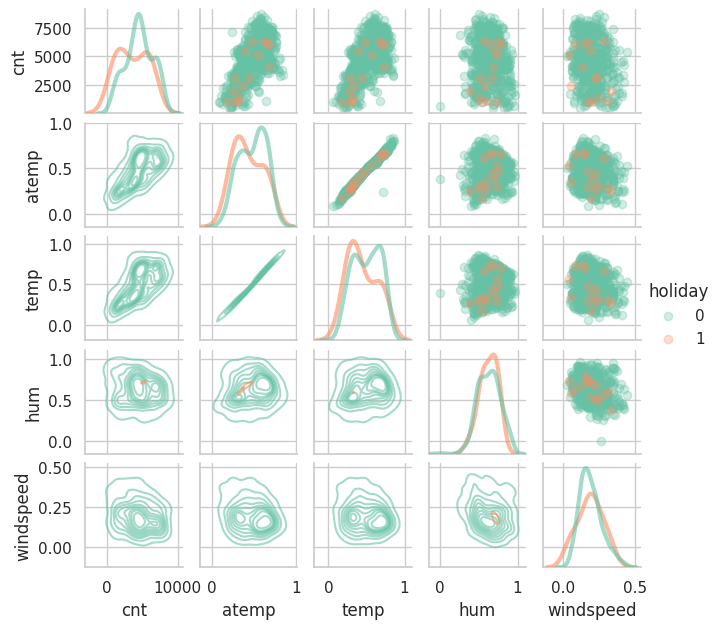

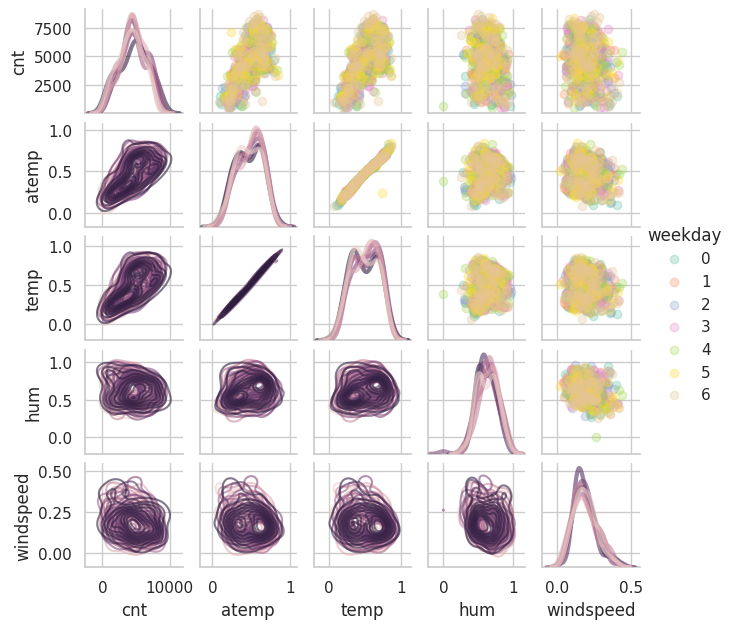

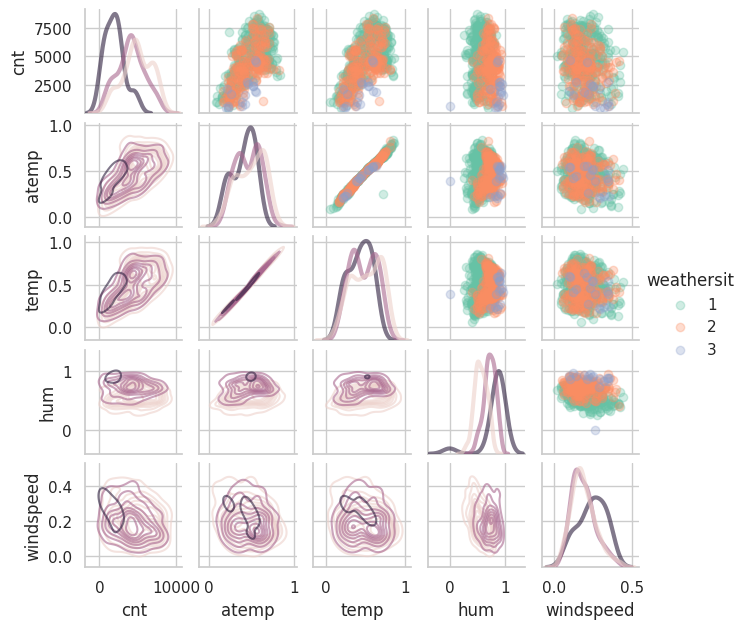

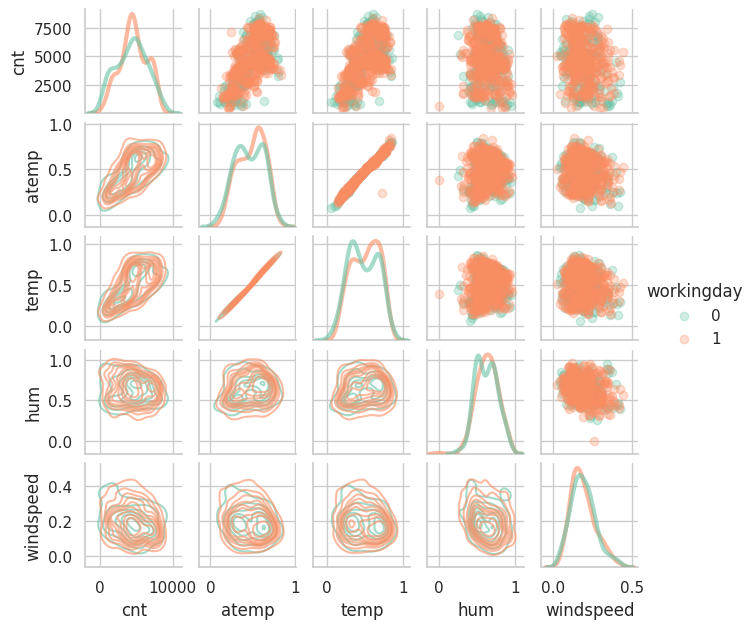

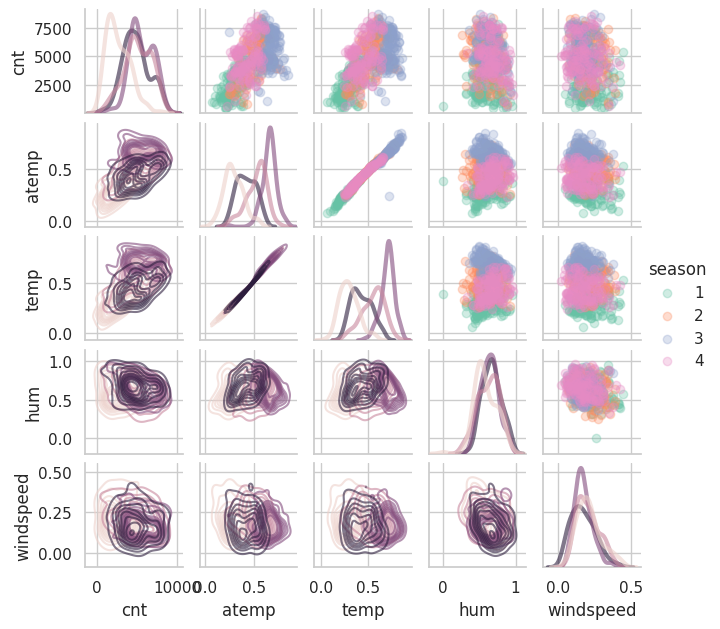

In [138]:
for hue in categorial_features:
    
    pair_grid = sns.PairGrid(train[["cnt", "atemp", "temp", "hum", "windspeed", hue]], hue=hue, diag_sharey=False, height=3)

    pair_grid.fig.set_size_inches(6, 6)
    pair_grid.map_lower(sns.kdeplot, alpha=0.6)
    pair_grid.map_upper(plt.scatter, alpha=0.3)
    pair_grid.map_diag(
        sns.kdeplot, lw=3, alpha=0.6, common_norm=False
    )

    pair_grid.add_legend()

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 4c1edb365b02e434e38deeb52b2096fa -->
Сделайте выводы по графикам. В частности, ответьте на следующие вопросы.
* Есть ли в данных явные выбросы, то есть точки, далеко находящиеся от основной массы точек?
* Стоит ли рассматривать какие-либо нелинейные функции от признаков? Не стоит придумывать сложные функции, достаточно рассмотреть $x^2$, $\log x$ и $I\{x > c\}$.



**Выводы по графикам:** Небольшие выбросы в данных присутствуют. Наибольшая корреляция cnt обнаружена с признаками atemp(из вещественных), wethersit и mnth(из категориальных). Обучем модель на всех представленнных на графиках признаках. Пока что нелинейных функций использовать не будем

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- e5fcb54a72af33e2c09b66124e63e5fc -->
#### 2. Подготовка данных

Опишите по шагам процедуру предобработки данных, которая будет включать работу с выбросами, преобразования вещественных и категориальных признаков, возможно, создание каких-либо новых признаков (посмотрите <a href="https://thetahat.ru/courses/ad/main/3/ad_linreg_sklearn">пример</a> с занятия). То, как именно выполнять подготовку данных, является целым исскуством. Здесь нет "правильного" подхода, здесь есть метрика качества на тестовом множестве, которая в последствии оценит качество вашей модели.

*Обратите внимание, от того, насколько качественно вы проведете визуальный анализ и подготовку данных, будет зависеть качество ваших моделей на следующих шагах.*

**Процедура предобработки данных:**

**а)**. Уберем с помощью анализа квартилей выбросы, считаем разность первого и третьего квартилей

In [140]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

Отфильтруем данные "квартирным методом"

In [141]:
outliers = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)
data_filtered = data[~outliers]

Разобьем на тестовую и тренировочную выборки

In [142]:
train, test = train_test_split(data_filtered, test_size=0.2, random_state=random_state)
train.shape, test.shape

((556, 11), (140, 11))

Теперь преобразуем категориальные признаки

In [144]:
encoder = OneHotEncoder(drop="first", sparse_output=False)  
train_cat = encoder.fit_transform(train[categorial_features])

In [157]:
X_train = np.hstack([train[real_features].to_numpy().reshape(-1, 4), train_cat])

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- c5124704b109dacbd9cf5647f50eb72c -->
#### 3. Обучение модели и ее анализ

Обучите линейную регрессию из `sklearn` на полученных данных и посмотрите на полученные оценки коэффициентов (в т.ч. свободный коэффициент).

In [158]:
model = LinearRegression()
model.fit(X_train, train[target_feature])

LinearRegression()

In [159]:
model.coef_, model.intercept_

(array([[ 1538.69130671, -3824.44854798,  5043.51503245, -3472.91186091,
           129.10247856,   317.15410779,    -9.38448451,   138.74709966,
          -374.73285699,  -821.58121025,   -64.6009704 ,   688.80043698,
           496.30676074,  -139.92306973,    10.8963161 ,  1050.09982418,
           669.21397812,  1460.30270204,   -86.71207855,    78.67293943,
            63.13889692,   131.60074619,   141.76258081,   426.9222577 ,
          -282.85433845, -1806.0166921 ,   328.4630848 ]]),
 array([3363.72635314]))

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 0e8e860f57fc7df75f236442f7206c78 -->
Посчитайте ошибку предсказания на тестовой выборке по метрикам RMSE, MAE, MAPE. Подробнее можно почитать в <a href="https://thetahat.ru/courses/ad/main/3/ad_linreg_sklearn">ноутбуке</a> с занятия.

*Замечание.* Если в тестовой части тоже есть "большие" выбросы, их стоит убрать. Наша модель не должна пытаться их предсказать (например, сбои в работе сервиса) но в то же время выбросы вносят существенный вклад в значение метрики. Особенно стоит обратить на это внимание в случае высоких значений метрик.

Преобразуем тестовые данные

In [160]:
test_cat = encoder.transform(test[categorial_features])
X_test = np.hstack([test[real_features].to_numpy().reshape(-1, 4), test_cat])

Теперь посчитаем предсказание

In [161]:
y_pred = model.predict(X_test)

In [162]:
rmse = np.sqrt(mean_squared_error(test[target_feature], y_pred))
mae = mean_absolute_error(test[target_feature], y_pred)           
mape = mean_absolute_percentage_error(test[target_feature], y_pred) * 100 

scores = pd.DataFrame({
    "RMSE": rmse,
    "MAE": mae,
    "MAPE": mape
}, index=[0])

scores

,RMSE,MAE,MAPE
0,1254.119524,1055.569171,29.574111


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 82920a034ed2865f8a7e2f03eaabceb6 -->
Попробуйте посчитать оценку коэффициентов с помощью формулы, полученной на занятии. Не забудьте про константный признак. В чем заключается проблема?

*Подсказка.* Подумайте о зависимостях между признаками. Причем, возможно, вы уже могли решить эту проблему на предыдущих этапах. В таком случае посмотрите, что будет, если "вернуть" проблему.

Уберем признак workingday, т.к. он тесно связан с holiday и weekday, для этого достаточно убрать последний столбец(т.к. нужно учесть и свободный член, то просто заменим последний столбец на столбец из единиц)

In [164]:
X_train[:,-1] = 1
X_test[:,-1] = 1

In [165]:
theta_matrix = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ train[target_feature]
predictions = X_test @ theta_matrix

scores = pd.DataFrame({
    "RMSE": np.sqrt(mean_squared_error(test[target_feature], predictions)),
    "MAE": mean_absolute_error(test[target_feature], predictions),
    "MAPE": mean_absolute_percentage_error(test[target_feature], predictions)
}, index=[0])

scores

,RMSE,MAE,MAPE
0,1254.119524,1055.569171,0.295741


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 56aff27d604dbe90dda7b28a8da4e2e9 -->
Исправьте эту проблему, посчитайте оценки коэффициентов, а также ошибку предсказания.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 52266029600cdfda3b1cfce9e68f5c99 -->
Если не убрать столбец workingday вылезет ождаемая ошибка singular matrix, т.к. для метода подсчета через матрицы важна линейная независимость столбцов

**Выводы:**

Получил хороший результат обученной модели на тестовой выборке. В данных присутствовали выбросы, от которых я избавился. Был обнаружен признак который зависит от  других, поэтому от него я тоже избавился

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 00000000000000000000000000000000 -->
*Замечание.* Не расстраивайтесь, если у вас получится не очень хорошее качество, это нормально. Вы провели только небольшую предобработку данных и обучили *простую* модель. Более сложные методы обработки данных и обучения ждут вас впереди. Главное &mdash; с чего-то начать!

<img src="https://thetahat.ru/files/ad/main/3/bike2.png">

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 2c0205cf5ab3ec02c6ea667faa01e48b -->
---
### Задача 3.

*Перед выполнением задачи ознакомтесь с <a href="https://thetahat.ru/courses/ad/main/3/ad_logreg_sklearn">ноутбуком по логистической регрессии</a> с занятия.*

> Одно из интересных свойств модели логистической регрессии — *при соблюдении её предположений* она дает возможность получать **несмещенные оценки вероятностей** принадлежности объекта к определенному классу.  
> Для пояснения рассмотрим объект $x$ и соответствующее предсказание вероятности $\widehat{p}(x)$ для класса 1. Если взять небольшую окрестность объекта $x$, то доля объектов класса 1 в этой окрестности будет приблизительно равна $\widehat{p}(x)$.  

Далее проверим это свойство на конкретных примерах.

С помощью кода ниже сгенерируйте данные, состоящие из одного вещественного признака и бинарного таргета.

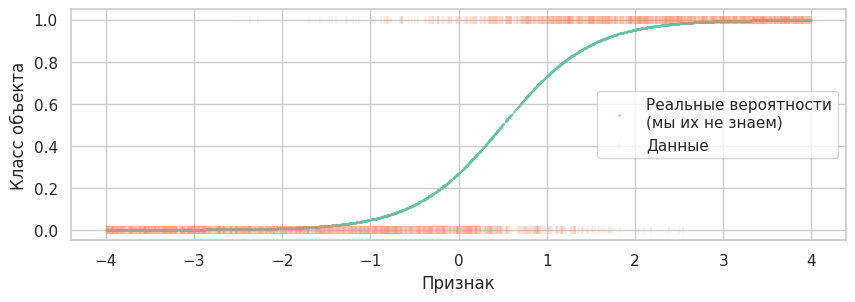

In [84]:
sample_size = 3000  # Размер выборки

# Признаки
X = np.random.uniform(low=-4, high=4, size=(sample_size, 1))

# Таргет
y_mean_true = 1 / (1 + np.exp(1 - 2 * X.ravel()))
y = np.random.binomial(n=1, p=y_mean_true)

plt.figure(figsize=(10, 3))
plt.scatter(X, y_mean_true, marker=".", s=1, label="Реальные вероятности\n(мы их не знаем)")
plt.scatter(X, y, marker="|", alpha=0.1, label="Данные")
plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend()

Обучите логистическую регрессию, используя реализацию из `sklearn`, при этом свободный коэффициент должен присутствовать в модели. Укажите также `penalty='none'`.

Напечатайте оценку коэффициентов

In [85]:
model = LogisticRegression(penalty=None, fit_intercept=True)
model.fit(X, y)

LogisticRegression(penalty=None)

In [86]:
print(f"Коэффициенты модели: w0={model.intercept_[0]:.4f}, w1={model.coef_[0][0]:.4f}")

Коэффициенты модели: w0=-1.0636, w1=2.0403


Ниже объявлена сетка значений признака. По этой сетке постройте
* предсказания классов,
* предсказания вероятностей класса 1.

Визуализируйте эти предсказания. На график стоит нанести также обучающую выборку.

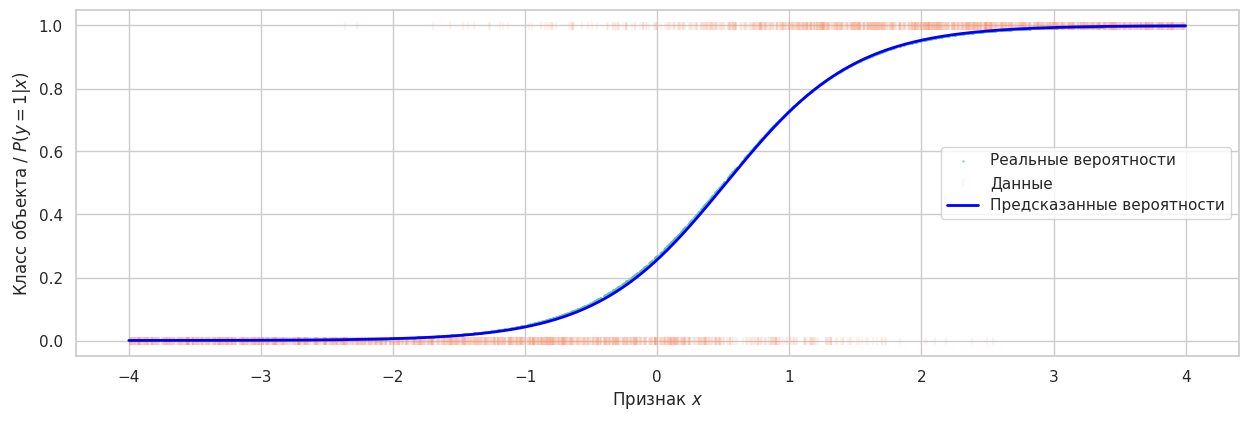

In [87]:
X_grid = np.linspace(-4, 4, 10000).reshape((-1, 1))
y_prob_grid = model.predict_proba(X_grid)[:, 1]

plt.figure(figsize=(15, 4.5))
plt.scatter(X, y_mean_true, marker=".", s=1, label="Реальные вероятности")
plt.scatter(X, y, marker="|", alpha=0.1, label="Данные")
plt.plot(X_grid, y_prob_grid, color='blue', label="Предсказанные вероятности", linewidth=2)
plt.xlabel("Признак $x$")
plt.ylabel("Класс объекта / $P(y=1|x)$")
plt.legend()
plt.show()

Разбейте отрезок $[-4, 4]$ на одинаковые бины длины длины 0.2 и посчитайте в каждом бине долю объектов класса 1. Полученные значения добавьте на график предсказаний вероятностей и сравните эти графики. Проинтерпретируйте полученные результаты.

*Подсказка:* может помочь `np.digitize` и метод `groupby` для таблиц `pandas`. Рекомендуем посмотреть <a href="https://thetahat.ru/courses/python">обучающие ноутбуки</a> по библиотекам.

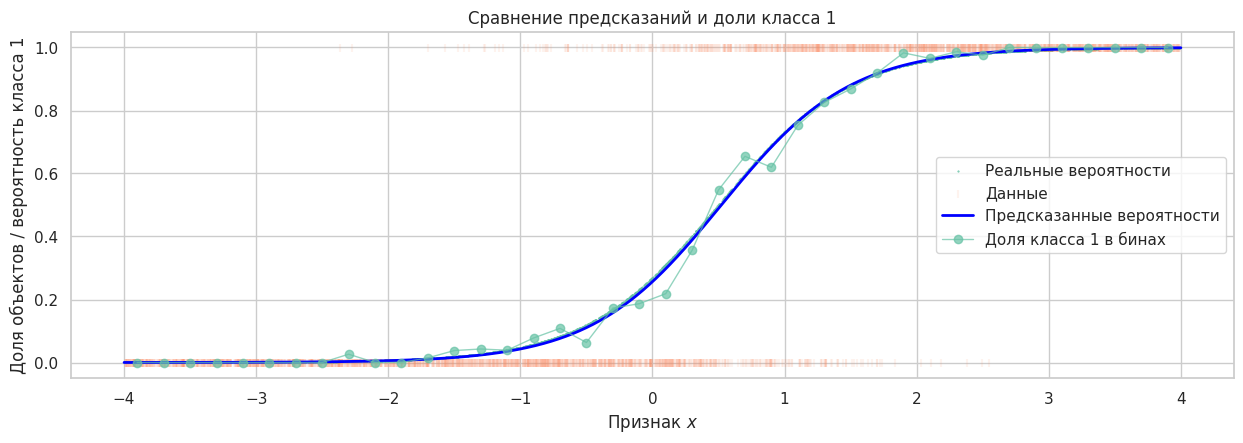

In [88]:
bin_edges = np.arange(-4, 4.2, 0.2)
bin_indices = np.digitize(X.ravel(), bin_edges)

df = pd.DataFrame({
    'X': X.ravel(),
    'y': y,
    'bin': bin_indices
})

bin_proportions = df.groupby('bin')['y'].mean()
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(15, 4.5))
plt.scatter(X, y_mean_true, marker=".", s=1, label="Реальные вероятности")
plt.scatter(X, y, marker="|", alpha=0.1, label="Данные")
plt.plot(X_grid, y_prob_grid, color='blue', label="Предсказанные вероятности", linewidth=2)
plt.plot(bin_centers, bin_proportions, alpha = 0.7, label="Доля класса 1 в бинах", marker='o', linewidth=1)
plt.xlabel("Признак $x$")
plt.ylabel("Доля объектов / вероятность класса 1")
plt.legend()
plt.title("Сравнение предсказаний и доли класса 1")
plt.grid(True)
plt.show()

Повторите проведенное исследование для следующих данных и сравните результаты.

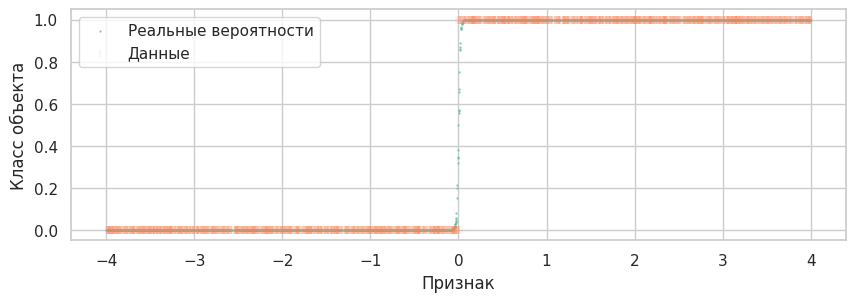

In [89]:
# Признаки
X = np.random.uniform(low=-4, high=4, size=(sample_size, 1))

# Таргет
y_mean_true = 1 / (1 + np.exp(-100 * X.ravel()))
y = np.random.binomial(n=1, p=y_mean_true)

plt.figure(figsize=(10, 3))
plt.scatter(X, y_mean_true, marker=".", s=1, label="Реальные вероятности")
plt.scatter(X, y, marker="|", alpha=0.1, label="Данные")
plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend()

In [90]:
model.fit(X, y)

LogisticRegression(penalty=None)

In [91]:
print(f"Коэффициенты модели: w0={model.intercept_[0]:.4f}, w1={model.coef_[0][0]:.4f}")

Коэффициенты модели: w0=-0.2396, w1=81.3475


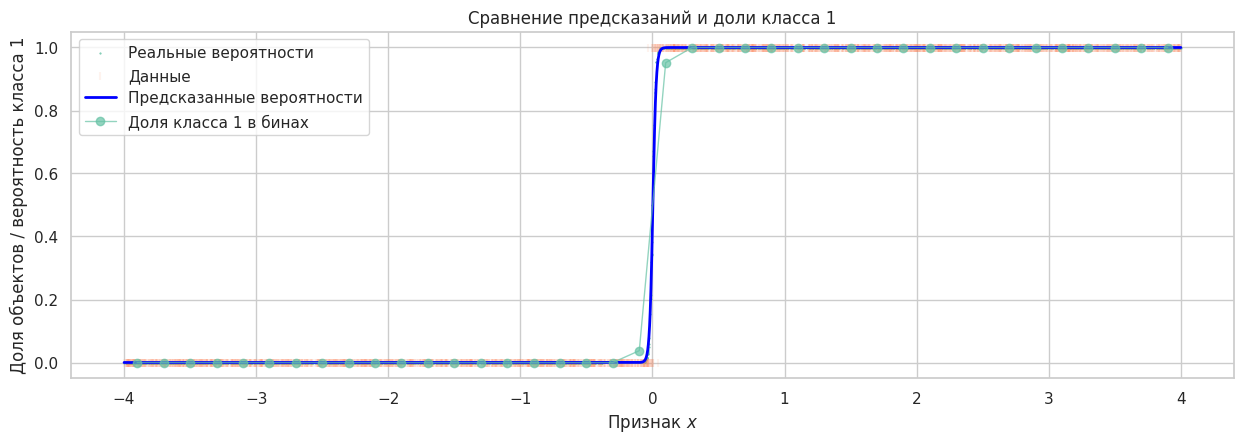

In [92]:
X_grid = np.linspace(-4, 4, 10000).reshape((-1, 1))
y_prob_grid = model.predict_proba(X_grid)[:, 1]

bin_edges = np.arange(-4, 4.2, 0.2)
bin_indices = np.digitize(X.ravel(), bin_edges)

df = pd.DataFrame({
    'X': X.ravel(),
    'y': y,
    'bin': bin_indices
})

bin_proportions = df.groupby('bin')['y'].mean()
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(15, 4.5))
plt.scatter(X, y_mean_true, marker=".", s=1, label="Реальные вероятности")
plt.scatter(X, y, marker="|", alpha=0.1, label="Данные")
plt.plot(X_grid, y_prob_grid, color='blue', label="Предсказанные вероятности", linewidth=2)
plt.plot(bin_centers, bin_proportions, alpha = 0.7, label="Доля класса 1 в бинах", marker='o', linewidth=1)
plt.xlabel("Признак $x$")
plt.ylabel("Доля объектов / вероятность класса 1")
plt.legend()
plt.title("Сравнение предсказаний и доли класса 1")
plt.grid(True)
plt.show()

**Выводы:**

Из-за более четкой границы между двумя классами во втором случае, мы получили результат точнее, чем в первым(точки долей объекта класса 1 в бине лучше ложаться на кривую, а также по кривой предсказаний можно с более высокой точностью определить принадлежность объекта классу)

---
### Задача 4.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- f92a2876d3f2b0d01fc396776be023a9 -->
Продолжим исследовать модель логистической регрессии. Сгенерируем данные, состоящие из двух бинарных признаков и бинарного таргета

In [93]:
probs = np.random.uniform(size=8)
probs /= probs.sum()
probs

x = np.random.choice(np.arange(8), p=probs, size=10000)
data = pd.DataFrame(
    np.unpackbits(np.array(x.reshape(-1, 1), dtype=">i8").view(np.uint8), axis=1)[:, -3:],
    columns=["feature_1", "feature_2", "target"],
)
data.head()

,feature_1,feature_2,target
0,0,1,1
1,0,1,1
2,0,1,1
3,0,0,1
4,0,0,1


Особенность таких данных &mdash; конечное число *возможных различных* объектов. В данном случае их всего 4, по количеству всех возможных комбинаций значений признака. Соответственно, любой моделью мы можем сделать только 4 *различных* предсказания. Исследуем, как с этим справляется логистическая регрессия.

Сначала для сравнения посчитайте долю класса 1 для каждой категории объектов.

*Подсказка:* используйте `pd.pivot_table`. Рекомендуем посмотреть <a href="https://thetahat.ru/courses/python">обучающие ноутбуки</a> по библиотекам.

In [94]:
pivot_table = pd.pivot_table(data, values='target', index='feature_1', columns='feature_2', aggfunc='mean')
pivot_table

feature_2,0,1
feature_1,,
0,0.899569,0.984053
1,0.416606,0.705930


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 14e68d57d58f901b3350e63f76b9f8db -->
Обучите логистическую регрессию с `penalty='none'` и получите предсказания вероятностей для этих четырех типов объектов. Представьте результаты в таком виде, чтобы их удобно было сравнивать с частотами, посчитанными ранее.

Возьмем данные для обучения

In [95]:
X = data[['feature_1', 'feature_2']].values
y = data['target'].values

Обучаем модельку

In [96]:
model = LogisticRegression(penalty=None, fit_intercept=True)
model.fit(X, y)

LogisticRegression(penalty=None)

Получим предсказания

In [97]:
combinations = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_prob = model.predict_proba(combinations)[:, 1]

In [98]:
pivot_pred = pd.DataFrame(
    y_prob.reshape(2, 2),
    index=[0, 1],
    columns=[0, 1]
)
pivot_pred.index.name = 'feature_1'
pivot_pred.columns.name = 'feature_2'
pivot_pred

feature_2,0,1
feature_1,,
0,0.916040,0.975781
1,0.406773,0.716885


Сконкатенируем таблицы для более наглядного сравнения

In [99]:
conc = pd.concat([pivot_table, pivot_pred], axis=1, keys=['Частота', 'Предсказание'])
conc

Частота           Предсказание          
feature_2         0         1            0         1
feature_1                                           
0          0.899569  0.984053     0.916040  0.975781
1          0.416606  0.705930     0.406773  0.716885

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 1b868a951c9dec0be47540d5316f7e9f -->
Почему результаты не совпадают?

Для ответа на этот вопрос распишите формулу, которая задает модель логистической регрессии, указав все параметры. Какое предположение о данных при этом делает логистическая регрессия?

Формула, задающая модель логистической регрессии в данном случае
$$
\hat{P}(x) = \frac{1}{1 + e^{-(\theta_0 + \theta_1 x_1 + \theta_2 x_2)}}
$$
Ее можно перписать в другом виде
$$
\log(\hat{P}(x)) - \log(1 - \hat{P}(x)) = \theta_0 + \theta_1 x_1 + \theta_2 x_2
$$
т.е. предполагается линейная зависимость между разностью логарифмов и признаками, что в нашем случае может быть не так, поэтому предлагается добавить 3-ий признак как произведение двух исходных.
$$
\log(\hat{P}(x)) - \log(1 - \hat{P}(x)) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1x_2
$$


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 1180c36f8ac39574c944b19ddee07271 -->
Предложите и реализуйте способ построения модели логистической регрессии так, чтобы она точнее предсказывала частоты, посчитанные ранее.

In [100]:
data['feature_3'] =  data['feature_1'] * data['feature_2']
X = data[['feature_1', 'feature_2', 'feature_3']].values
y = data['target'].values

In [101]:
model = LogisticRegression(penalty=None, fit_intercept=True)
model.fit(X, y)

LogisticRegression(penalty=None)

In [102]:
combinations = np.array([[0, 0, 0], [0, 1, 0], [1, 0, 0], [1, 1, 1]])
y_prob = model.predict_proba(combinations)[:, 1]

In [103]:
pivot_pred = pd.DataFrame(
    y_prob.reshape(2, 2),
    index=[0, 1],
    columns=[0, 1]
)
pivot_pred.index.name = 'feature_1'
pivot_pred.columns.name = 'feature_2'

In [104]:
conc = pd.concat([pivot_table, pivot_pred], axis=1, keys=['Частота', 'Предсказание'])
conc

Частота           Предсказание          
feature_2         0         1            0         1
feature_1                                           
0          0.899569  0.984053     0.899497  0.984023
1          0.416606  0.705930     0.416592  0.705819

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 3f951c224a4ac471c658ed7755ff9521 -->
**Выводы:**

Видно, что при добавление нелинейного признака предсказания улучшились многократно. Все из-за того, что логистическая регрессия работает в предположение линейной зависимости описанных выше величин. Мы добились линейной зависимости, добавив искусственно 3-ий признак к нашей модели

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 00000000000000000000000000000000 -->
---
### <font color="orange"><i>Сложная часть</i></font>

Задачи 5-7: скачайте второй ноутбук с условием задания со страницы курса.